Chart Analysis
Use Python to retrieve stock market data and analyze price changes.
1. Fetch both daily and hourly stock market data using a suitable API.
Visualize the data in several types of plots.
2. Plot long-term stock data over multiple years.
Create an interactive graph that allows the user to view different time ranges.
3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.
4. Add moving averages to the stock charts, such as:
○ SMA20 and SMA50, or
○ SMA50 and SMA150
These should be overlaid on the main stock price chart.
5. Create a table for five stocks. Use default examples such as FAANG stocks plus
NVIDIA, but allow the user to change them.
For each stock, calculate the historical probability that the next day is positive if the
current day changes by:
+2%, +3%, +4%, +5%, and +6%.
Example: if Apple rises 5% today, what is the historical probability that the next day
closes positive?
Use the last 2 years of historical data.
6. Repeat the same analysis for negative daily moves, such as:
-2%, -3%, -4%, and -5%.
7. Repeat both of the above analyses again using 5 years of historical data.
8. Create a comparison table for the five selected stocks.
Include a simple correlation / collinearity analysis between them.
9. Plot a comparison chart for two to five stocks using daily data for one year.
Example: compare Apple and Amazon.
Normalize or rescale prices if needed so they can be compared clearly.
10. Create another table for the same five stocks showing the probability that the next day
is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days
11. Repeat the same analysis for consecutive negative days.
12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked
by daily percentage change.
13. Repeat the screening, but only include stocks with a market capitalization of $5 billion
or more.
This may require obtaining market cap data from an API or web scraping source.

I will be using the Massive API, formerly polygon.io. Massive obtains its data from an aggregate of all major US stock exchanges. The plan I am selecting provides 5 years of historical data.

# 1. Downloading Data - AKA the beast
This function downloaded over 5000 stocks. I never planned on using them all, but it is useful to have them all in front of me for decision-making. I commented out this entire block because it took about an hour to run, and my API access will be gone soon anyway.

Some storage paths may be different from the final result. Changing the code doesn't matter since I probably won't run this code again anyway, but if I think of it I will try to make it match anyway for the sake of cleanliness.

In [ ]:
%%time

import requests
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import time


# -------------------------
# SETTINGS
# -------------------------

API_KEY_PATH = "api_keys/massive.txt"
SAVE_FOLDER = "raw_daily_data"
COMBINED_OUTPUT_FILE = "raw_daily_data/combined_daily_data.csv"

YEARS = 5
SAFETY_DAYS = 1
RATE_LIMIT_SECONDS = 0.2


MANUAL_TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN",
    "TSLA", "NFLX", "JPM", "WMT", "SPY"
]


FILTER_PROFILES = {
    "common_stocks": {
        "types": ["CS"],
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "common_stocks_and_adrs": {
        "types": ["CS", "ADR"],
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "etfs": {
        "types": ["ETF"],
        "exchanges": ["ARCX", "XNAS", "XNYS"],
        "active": True,
    },
    "everything_major_exchanges": {
        "types": None,
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "manual_test": {
        "manual_tickers": MANUAL_TICKERS,
    },
    "common_stocks_plus_fb": {
        "types": ["CS"],
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
        "include_tickers": ["FB"],
    },
}



# Choose one of these:
# (Common_stocks_plus_fb is the one to run if I have to do this again)
FILTER_PROFILE = "common_stocks_plus_fb"
# FILTER_PROFILE = "common_stocks"
# FILTER_PROFILE = "common_stocks_and_adrs"
# FILTER_PROFILE = "etfs"
# FILTER_PROFILE = "everything_major_exchanges"
# FILTER_PROFILE = "manual_test"


# -------------------------
# API HELPERS
# -------------------------

def load_api_key(filepath=API_KEY_PATH):
    return Path(filepath).read_text(encoding="utf-8").strip()


def get_all_pages(url, params=None):
    all_results = []

    api_key = params.get("apiKey") if params else None

    while url:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if data.get("status") == "NOT_AUTHORIZED":
            raise PermissionError(data.get("message", "Not authorized for this request."))

        all_results.extend(data.get("results", []))

        url = data.get("next_url")

        if url and api_key and "apiKey=" not in url:
            separator = "&" if "?" in url else "?"
            url = f"{url}{separator}apiKey={api_key}"

        params = None

    return all_results


# -------------------------
# TICKER UNIVERSE
# -------------------------

def get_massive_ticker_reference(api_key_path=API_KEY_PATH):
    api_key = load_api_key(api_key_path)

    url = "https://api.massive.com/v3/reference/tickers"

    params = {
        "market": "stocks",
        "active": "true",
        "sort": "ticker",
        "limit": 1000,
        "apiKey": api_key,
    }

    results = get_all_pages(url, params)

    if not results:
        raise ValueError("No ticker reference data returned.")

    return pd.DataFrame(results)


def apply_ticker_filter(df_tickers, profile_name):
    profile = FILTER_PROFILES[profile_name]

    if "manual_tickers" in profile:
        tickers = profile["manual_tickers"]
        return df_tickers[df_tickers["ticker"].isin(tickers)].copy(), tickers

    filtered = df_tickers.copy()

    if profile.get("active") is not None:
        filtered = filtered[filtered["active"] == profile["active"]]

    if profile.get("types") is not None:
        filtered = filtered[filtered["type"].isin(profile["types"])]

    if profile.get("exchanges") is not None:
        filtered = filtered[filtered["primary_exchange"].isin(profile["exchanges"])]

    filtered = filtered.sort_values("ticker").reset_index(drop=True)

    tickers = filtered["ticker"].tolist()

    return filtered, tickers


# -------------------------
# DAILY BAR FETCHING
# -------------------------

def get_massive_daily_bars(
    ticker,
    api_key_path=API_KEY_PATH,
    years=YEARS,
    safety_days=SAFETY_DAYS,
    adjusted=True,
    sort="asc"
):
    api_key = load_api_key(api_key_path)

    today = date.today()
    start_date = today - relativedelta(years=years) + timedelta(days=safety_days)

    url = (
        f"https://api.massive.com/v2/aggs/ticker/"
        f"{ticker}/range/1/day/{start_date.isoformat()}/{today.isoformat()}"
    )

    params = {
        "adjusted": str(adjusted).lower(),
        "sort": sort,
        "limit": 50000,
        "apiKey": api_key,
    }

    results = get_all_pages(url, params)

    if not results:
        raise ValueError(f"No data returned for {ticker}.")

    df = pd.DataFrame(results).rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "transactions",
    })

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms").dt.date
    df["ticker"] = ticker

    preferred_order = [
        "timestamp", "ticker", "open", "high", "low", "close",
        "volume", "vwap", "transactions"
    ]

    return df[[col for col in preferred_order if col in df.columns]]


def fetch_save_and_return_ticker(
    ticker,
    save_folder=SAVE_FOLDER,
    overwrite=False
):
    Path(save_folder).mkdir(exist_ok=True)

    filename = Path(save_folder) / f"daily_{ticker.lower()}.csv"

    if filename.exists() and not overwrite:
        df = pd.read_csv(filename)
        print(f"{ticker} already exists. Loaded from disk.")
        return df

    df = get_massive_daily_bars(ticker)
    df.to_csv(filename, index=False)

    print(f"{ticker} saved to {filename}")
    return df


# -------------------------
# MAIN PIPELINE
# -------------------------

df_all_tickers = get_massive_ticker_reference()

df_filtered_tickers, tickers = apply_ticker_filter(
    df_all_tickers,
    FILTER_PROFILE
)

print(f"Filter profile: {FILTER_PROFILE}")
print(f"Tickers selected: {len(tickers)}")

data = {}
failed = []

for ticker in tickers:
    try:
        df = fetch_save_and_return_ticker(ticker)
        data[ticker] = df
        time.sleep(RATE_LIMIT_SECONDS)

    except Exception as e:
        print(f"{ticker} failed: {e}")
        failed.append({
            "ticker": ticker,
            "error": str(e)
        })


# -------------------------
# COMBINED DATAFRAME
# -------------------------

if data:
    combined_df = pd.concat(data.values(), ignore_index=True)
    combined_df = combined_df.sort_values(["ticker", "timestamp"]).reset_index(drop=True)

    combined_df.to_csv(COMBINED_OUTPUT_FILE, index=False)

    print(f"Combined dataframe shape: {combined_df.shape}")
    print(f"Combined file saved to: {COMBINED_OUTPUT_FILE}")
else:
    combined_df = pd.DataFrame()
    print("No data was successfully fetched.")


failed_df = pd.DataFrame(failed)

if not failed_df.empty:
    failed_df.to_csv("failed_tickers.csv", index=False)
    print(f"Failed tickers saved: {len(failed_df)}")


# This is going to take a really long time, so we'll play a nice fanfare when it's done!
# Comment these out if you don't have FFMPEG installed
from pydub import AudioSegment
from pydub.playback import play
play(AudioSegment.from_file("BOTW_RARE_ITEM_GET.mp3"))

Filter profile: common_stocks_plus_fb
Tickers selected: 5039
A saved to raw_daily_data/daily_a.csv
AA saved to raw_daily_data/daily_aa.csv
AACB saved to raw_daily_data/daily_aacb.csv
AACI saved to raw_daily_data/daily_aaci.csv
AACO saved to raw_daily_data/daily_aaco.csv
AAL saved to raw_daily_data/daily_aal.csv
AAME saved to raw_daily_data/daily_aame.csv
AAMI saved to raw_daily_data/daily_aami.csv
AAOI saved to raw_daily_data/daily_aaoi.csv
AAON saved to raw_daily_data/daily_aaon.csv
AAP saved to raw_daily_data/daily_aap.csv
AAPL saved to raw_daily_data/daily_aapl.csv
AARD saved to raw_daily_data/daily_aard.csv
AAT saved to raw_daily_data/daily_aat.csv
AAUC saved to raw_daily_data/daily_aauc.csv
AB saved to raw_daily_data/daily_ab.csv
ABAT saved to raw_daily_data/daily_abat.csv
ABBV saved to raw_daily_data/daily_abbv.csv
ABCB saved to raw_daily_data/daily_abcb.csv
ABCL saved to raw_daily_data/daily_abcl.csv
ABEO saved to raw_daily_data/daily_abeo.csv
ABG saved to raw_daily_data/daily_a

# 2. Filtering
Now with everything downloaded, I have to decide what to keep.

I already have my combined dataframe. I'll find the average daily transactions across the entire dataset. and then determine a cutoff threshold.

After I choose the stocks here, my intention is to use the same list for hourly data, but I am worried it 

In [26]:
# If kernel restarts, can start here by loading the DataFrame from an already prepared CSV.

# import pandas as pd
# combined_df = pd.read_csv('raw_daily_data_SAFE_2026_05_02/combined_daily_data.csv')

In [3]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-03,A,134.290,134.3099,132.61,133.19,1.043174e+06,133.1504,16226.0
1,2021-05-04,A,132.120,132.5100,130.35,130.90,1.769740e+06,130.8918,26856.0
2,2021-05-05,A,132.090,134.0900,131.25,133.37,1.447574e+06,133.1998,19877.0
3,2021-05-06,A,132.310,132.6000,130.77,132.40,1.173755e+06,131.8933,20455.0
4,2021-05-07,A,133.190,134.8200,133.19,133.90,1.056246e+06,133.9869,17352.0
...,...,...,...,...,...,...,...,...,...
4989897,2026-04-27,ZYME,27.930,29.7500,27.93,28.56,9.502180e+05,28.8344,13412.0
4989898,2026-04-28,ZYME,28.610,28.8850,27.92,27.94,4.214716e+05,28.1324,9773.0
4989899,2026-04-29,ZYME,27.520,27.9500,26.77,27.83,8.244088e+05,27.7028,13249.0
4989900,2026-04-30,ZYME,27.975,28.1850,27.18,27.54,4.826677e+05,27.5929,11679.0


In [60]:
combined_df[combined_df['ticker'] == 'FB']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions


# Adding Facebook

My above function missed Facebook because I set my tickers for only active tickers. I'll pull it individually and add it manually. If I re-run the function with the fix to include FB (may have to do it anyway to keep my 5 year window), much of this section can be bypassed.

In [82]:
def get_fb_daily_data(
    api_key_path="api_keys/massive.txt",
    years=10,   # go longer since FB is historical now
    safety_days=1
):
    """
    Fetch historical daily data for FB (Facebook pre-META).
    """

    try:
        df = get_massive_daily_bars(
            ticker="FB",
            api_key_path=api_key_path,
            years=years,
            safety_days=safety_days
        )

        # Ensure datetime (not just date) for consistency with your pipeline
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        return df

    except Exception as e:
        print(f"FB fetch failed: {e}")
        return pd.DataFrame()

df_fb = get_fb_daily_data(years=10)

from pathlib import Path

Path("raw_daily_data").mkdir(exist_ok=True)

df_fb.to_csv("raw_daily_data/daily_fb.csv", index=False)

# To play a triumphant fanfare when it finishes
from pydub import AudioSegment
from pydub.playback import play
play(AudioSegment.from_file("BOTW_RARE_ITEM_GET.mp3"))

Input #0, wav, from '/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/tmpinv9g3d4.wav':
  Duration: 00:00:07.31, bitrate: 1411 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 44100 Hz, 2 channels, s16, 1411 kb/s


In [83]:
df_fb

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,FB,318.1900,321.0600,314.4900,315.0200,1.557060e+07,317.3538,201397
1,2021-05-06,FB,314.5200,320.2400,313.2750,320.0200,1.901224e+07,317.5020,218059
2,2021-05-07,FB,322.3800,322.9350,318.7500,319.0800,1.591674e+07,320.4781,209827
3,2021-05-10,FB,314.3500,314.5786,304.8300,305.9700,2.423917e+07,307.8293,324498
4,2021-05-11,FB,300.7500,306.8400,299.6900,306.5300,1.892009e+07,303.8195,281399
...,...,...,...,...,...,...,...,...,...
486,2026-04-27,FB,43.6148,43.6148,43.6148,43.6148,2.639097e+01,43.6527,19
487,2026-04-28,FB,43.6090,43.6090,43.5697,43.5697,2.479427e+02,43.6032,16
488,2026-04-29,FB,43.5900,43.5900,43.5317,43.5317,1.769432e+02,43.5884,21
489,2026-04-30,FB,43.7301,43.7301,43.7301,43.7301,7.901293e+01,43.5953,17


In [98]:
super_combined_df = pd.concat([combined_df, df_fb], axis=0)

super_combined_df['timestamp'] = pd.to_datetime(super_combined_df['timestamp']).dt.date

df_metafb_fix = super_combined_df.copy()

df_metafb_fix["timestamp"] = pd.to_datetime(df_metafb_fix["timestamp"])

In [99]:
# Keep FB through 2022-06-08
# Keep META from 2022-06-09 onward
df_metafb_fix = df_metafb_fix[
    ~((df_metafb_fix["ticker"] == "FB") & (df_metafb_fix["timestamp"] >= "2022-06-09"))
]

df_metafb_fix = df_metafb_fix[
    ~((df_metafb_fix["ticker"] == "META") & (df_metafb_fix["timestamp"] < "2022-06-09"))
]

df_metafb_fix["ticker"] = df_metafb_fix["ticker"].replace({"FB": "META"})

There should no longer be any FB data.

In [100]:
df_metafb_fix[df_metafb_fix['ticker'] == 'FB']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions


META should have full data from the beginning of the dataset.

In [101]:
df_metafb_fix[df_metafb_fix['ticker'] == 'META']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
2852959,2022-06-09,META,194.28,199.450,183.6800,184.00,23501579.0,190.7486,282457.0
2852960,2022-06-10,META,183.04,183.100,175.0200,175.57,27478354.0,177.3336,366773.0
2852961,2022-06-13,META,170.59,172.575,164.0300,164.26,31749304.0,167.2440,440307.0
2852962,2022-06-14,META,166.03,166.750,161.3601,163.73,27192049.0,163.7958,341928.0
2852963,2022-06-15,META,167.20,172.160,163.9750,169.35,29808251.0,167.5321,340902.0
...,...,...,...,...,...,...,...,...,...
272,2022-06-02,META,188.45,200.935,187.7300,198.86,31951582.0,195.8094,336899.0
273,2022-06-03,META,195.98,196.610,189.7800,190.78,19464993.0,192.0885,239486.0
274,2022-06-06,META,193.99,196.920,188.4000,194.25,30574242.0,193.2857,307707.0
275,2022-06-07,META,191.93,196.530,191.4900,195.65,18628687.0,194.4583,204288.0


Just need to re-sort.

In [102]:
#df_metafb_fix = df_metafb_fix.sort_values("timestamp").reset_index(drop=True)


df_metafb_fix = df_metafb_fix.sort_values(by=['ticker', 'timestamp'])


Now it should be in order.

In [104]:
df_metafb_fix[df_metafb_fix['ticker'] == 'META']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,META,318.190,321.0600,314.4900,315.020,1.557060e+07,317.3538,201397.0
1,2021-05-06,META,314.520,320.2400,313.2750,320.020,1.901224e+07,317.5020,218059.0
2,2021-05-07,META,322.380,322.9350,318.7500,319.080,1.591674e+07,320.4781,209827.0
3,2021-05-10,META,314.350,314.5786,304.8300,305.970,2.423917e+07,307.8293,324498.0
4,2021-05-11,META,300.750,306.8400,299.6900,306.530,1.892009e+07,303.8195,281399.0
...,...,...,...,...,...,...,...,...,...
2853931,2026-04-27,META,670.995,682.5000,670.8400,678.620,1.274664e+07,677.2405,336701.0
2853932,2026-04-28,META,674.240,678.1800,665.6250,671.340,1.060559e+07,671.0503,323398.0
2853933,2026-04-29,META,668.910,674.2500,663.8084,669.120,1.904737e+07,658.9351,570557.0
2853934,2026-04-30,META,619.320,620.8500,600.0000,611.910,5.276516e+07,609.3627,1505192.0


In [113]:
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-03,A,134.290,134.3099,132.61,133.19,1.043174e+06,133.1504,16226.0
1,2021-05-04,A,132.120,132.5100,130.35,130.90,1.769740e+06,130.8918,26856.0
2,2021-05-05,A,132.090,134.0900,131.25,133.37,1.447574e+06,133.1998,19877.0
3,2021-05-06,A,132.310,132.6000,130.77,132.40,1.173755e+06,131.8933,20455.0
4,2021-05-07,A,133.190,134.8200,133.19,133.90,1.056246e+06,133.9869,17352.0
...,...,...,...,...,...,...,...,...,...
4989897,2026-04-27,ZYME,27.930,29.7500,27.93,28.56,9.502180e+05,28.8344,13412.0
4989898,2026-04-28,ZYME,28.610,28.8850,27.92,27.94,4.214716e+05,28.1324,9773.0
4989899,2026-04-29,ZYME,27.520,27.9500,26.77,27.83,8.244088e+05,27.7028,13249.0
4989900,2026-04-30,ZYME,27.975,28.1850,27.18,27.54,4.826677e+05,27.5929,11679.0


In [117]:
df_metafb_fix.to_csv('combined_daily_data_with_fbmeta_fix.csv', index=False)
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-03,A,134.290,134.3099,132.61,133.19,1.043174e+06,133.1504,16226.0
1,2021-05-04,A,132.120,132.5100,130.35,130.90,1.769740e+06,130.8918,26856.0
2,2021-05-05,A,132.090,134.0900,131.25,133.37,1.447574e+06,133.1998,19877.0
3,2021-05-06,A,132.310,132.6000,130.77,132.40,1.173755e+06,131.8933,20455.0
4,2021-05-07,A,133.190,134.8200,133.19,133.90,1.056246e+06,133.9869,17352.0
...,...,...,...,...,...,...,...,...,...
4989897,2026-04-27,ZYME,27.930,29.7500,27.93,28.56,9.502180e+05,28.8344,13412.0
4989898,2026-04-28,ZYME,28.610,28.8850,27.92,27.94,4.214716e+05,28.1324,9773.0
4989899,2026-04-29,ZYME,27.520,27.9500,26.77,27.83,8.244088e+05,27.7028,13249.0
4989900,2026-04-30,ZYME,27.975,28.1850,27.18,27.54,4.826677e+05,27.5929,11679.0


# RESTART POINT IN CASE OF KERNEL PROBLEM

In [2]:
import pandas as pd
df_metafb_fix = pd.read_csv('combined_daily_data_with_fbmeta_fix.csv')
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-03,A,134.290,134.3099,132.61,133.19,1.043174e+06,133.1504,16226.0
1,2021-05-04,A,132.120,132.5100,130.35,130.90,1.769740e+06,130.8918,26856.0
2,2021-05-05,A,132.090,134.0900,131.25,133.37,1.447574e+06,133.1998,19877.0
3,2021-05-06,A,132.310,132.6000,130.77,132.40,1.173755e+06,131.8933,20455.0
4,2021-05-07,A,133.190,134.8200,133.19,133.90,1.056246e+06,133.9869,17352.0
...,...,...,...,...,...,...,...,...,...
4990026,2026-04-27,ZYME,27.930,29.7500,27.93,28.56,9.502180e+05,28.8344,13412.0
4990027,2026-04-28,ZYME,28.610,28.8850,27.92,27.94,4.214716e+05,28.1324,9773.0
4990028,2026-04-29,ZYME,27.520,27.9500,26.77,27.83,8.244088e+05,27.7028,13249.0
4990029,2026-04-30,ZYME,27.975,28.1850,27.18,27.54,4.826677e+05,27.5929,11679.0


In [3]:
df_ticker_aggs = (
    df_metafb_fix.groupby('ticker')['transactions']
    .mean()
    .reset_index()
    .rename(columns={'transactions': 'avg_daily_transactions'})
)

df_ticker_aggs = df_ticker_aggs.sort_values(by='avg_daily_transactions', ascending=False)
df_ticker_aggs['adt_INT'] = df_ticker_aggs['avg_daily_transactions'].astype('int64')
df_ticker_aggs.head(20)

,ticker,avg_daily_transactions,adt_INT
3236,NVDA,1.177685e+06,1177684
4539,TSLA,1.170281e+06,1170281
11,AAPL,6.477312e+05,647731
254,AMD,4.828164e+05,482816
283,AMZN,4.650906e+05,465090
3000,MSFT,4.150247e+05,415024
1984,GOOGL,3.578033e+05,357803
3578,PLTR,3.538267e+05,353826
2869,META,3.274634e+05,327463
2342,INTC,2.767172e+05,276717


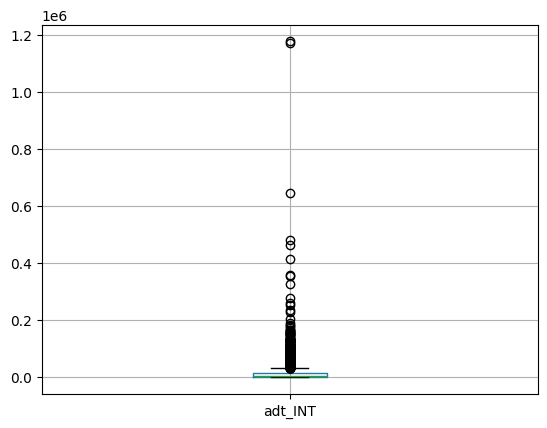

In [4]:
import matplotlib.pyplot as plt

df_ticker_aggs.boxplot(column='adt_INT')
plt.show()

In [5]:
from scipy.stats import iqr
import numpy as np


result = iqr(df_ticker_aggs['avg_daily_transactions'])

print(f"IQR: {result}")

IQR: 12296.26771513169


In [6]:
thresholds = [5000, 10000, 15000, 20000, 25000, 30000, 40000, 50000, 100000]

for t in thresholds:
    count = (df_ticker_aggs['adt_INT'] >= t).sum()
    print(f">={t}: {count}")

>=5000: 2745
>=10000: 1752
>=15000: 1188
>=20000: 859
>=25000: 666
>=30000: 523
>=40000: 353
>=50000: 243
>=100000: 71


In [7]:
combined_df_exp = pd.merge(df_metafb_fix, df_ticker_aggs, on='ticker')


df_stocks_30000_transacs = combined_df_exp[combined_df_exp['avg_daily_transactions'] >= 30000]
df_stocks_30000_transacs

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_daily_transactions,adt_INT
1256,2021-05-03,AA,37.18,38.055,36.050,37.61,4.750167e+06,37.1793,33888.0,57607.252389,57607
1257,2021-05-04,AA,38.02,39.270,37.650,39.07,6.818444e+06,38.7325,52028.0,57607.252389,57607
1258,2021-05-05,AA,39.37,40.880,38.640,40.60,7.773673e+06,40.1427,54715.0,57607.252389,57607
1259,2021-05-06,AA,40.89,41.440,39.280,39.89,7.308031e+06,40.0879,52580.0,57607.252389,57607
1260,2021-05-07,AA,39.76,41.380,39.250,41.20,4.909460e+06,40.6481,40057.0,57607.252389,57607
...,...,...,...,...,...,...,...,...,...,...,...
4982308,2026-04-27,ZTS,116.62,119.680,116.600,117.87,3.160355e+06,118.2275,43149.0,37887.344223,37887
4982309,2026-04-28,ZTS,117.23,118.290,116.075,116.65,2.972547e+06,117.0538,47388.0,37887.344223,37887
4982310,2026-04-29,ZTS,115.50,115.905,112.970,113.83,3.401808e+06,113.9745,47839.0,37887.344223,37887
4982311,2026-04-30,ZTS,114.04,115.535,113.790,114.97,4.297206e+06,114.7143,57409.0,37887.344223,37887


In [9]:
(df_stocks_30000_transacs['ticker'] == 'META').sum()

np.int64(1254)

On a previous run this showed 1254. This is to be expected considering the time loss between data gathering, and should be fixed once data is redownloaded.

In [ ]:
Now we should drop anything without value_counts meeting a threshold.

In [9]:
df_stocks_30000_transacs['ticker'].value_counts()

ticker
AA      1256
AMZN    1256
WMT     1256
TSLA    1256
NVDA    1256
        ... 
XE         6
AVLN       2
COAG       1
SPTX       1
UCFI       1
Name: count, Length: 523, dtype: int64

In [13]:
df_30000_imp = df_stocks_30000_transacs.copy()

# Define your threshold
# threshold = 1254

# Calculate counts for each value in Column B
# ticker_counts = df_30000_imp['ticker'].value_counts()

# Keep rows where the value in 'B' appears at least 'threshold' times
df_30000_imp = df_30000_imp[df_30000_imp['ticker'].map(df_30000_imp['ticker'].value_counts()) >= 1254]

df_30000_imp

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_daily_transactions,adt_INT
1256,2021-05-03,AA,37.18,38.055,36.050,37.61,4.750167e+06,37.1793,33888.0,57607.252389,57607
1257,2021-05-04,AA,38.02,39.270,37.650,39.07,6.818444e+06,38.7325,52028.0,57607.252389,57607
1258,2021-05-05,AA,39.37,40.880,38.640,40.60,7.773673e+06,40.1427,54715.0,57607.252389,57607
1259,2021-05-06,AA,40.89,41.440,39.280,39.89,7.308031e+06,40.0879,52580.0,57607.252389,57607
1260,2021-05-07,AA,39.76,41.380,39.250,41.20,4.909460e+06,40.6481,40057.0,57607.252389,57607
...,...,...,...,...,...,...,...,...,...,...,...
4982308,2026-04-27,ZTS,116.62,119.680,116.600,117.87,3.160355e+06,118.2275,43149.0,37887.344223,37887
4982309,2026-04-28,ZTS,117.23,118.290,116.075,116.65,2.972547e+06,117.0538,47388.0,37887.344223,37887
4982310,2026-04-29,ZTS,115.50,115.905,112.970,113.83,3.401808e+06,113.9745,47839.0,37887.344223,37887
4982311,2026-04-30,ZTS,114.04,115.535,113.790,114.97,4.297206e+06,114.7143,57409.0,37887.344223,37887


In [14]:
df_30000_imp['ticker'].value_counts()

ticker
AA       1256
WMT      1256
JPM      1256
GOOGL    1256
MSFT     1256
         ... 
EA       1255
ZTS      1255
META     1254
NVAX     1254
CLSK     1254
Name: count, Length: 398, dtype: int64

# OLD FBMETA fix - this is now being done earlier

# Everything below here can probably be dropped, important stuff pulled from alt notebook

Below we will still have to do some data cleaning. Notably the FB/META problem, which value counts will likely reveal. May ask AI if any others in this list have been subject to a name change.

Meta was previously known as Facebook until 2022-06-08. The ticker 'FB' was used through that day, and switched to 'META' starting 2022-06-09.

In [54]:
df_stocks_30000_transacs_meta_fix = df_stocks_30000_transacs.copy()

# Ensure datetime
df_stocks_30000_transacs_meta_fix['timestamp'] = pd.to_datetime(
    df_stocks_30000_transacs_meta_fix['timestamp']
)

# Define cutoff as datetime
cutoff = pd.Timestamp('2022-06-09')

# Drop META before cutoff
meta_drop_condition = (
    (df_stocks_30000_transacs_meta_fix['ticker'] == 'META') &
    (df_stocks_30000_transacs_meta_fix['timestamp'] < cutoff)
)

# Drop FB after cutoff
fb_drop_condition = (
    (df_stocks_30000_transacs_meta_fix['ticker'] == 'FB') &
    (df_stocks_30000_transacs_meta_fix['timestamp'] > cutoff - pd.Timedelta(days=1))
)

# Apply filters
df_stocks_30000_transacs_meta_fix = df_stocks_30000_transacs_meta_fix[
    ~(meta_drop_condition | fb_drop_condition)
]

# Replace FB → META
df_stocks_30000_transacs_meta_fix['ticker'] = (
    df_stocks_30000_transacs_meta_fix['ticker']
    .replace({'FB': 'META'})
)


df_stocks_30000_transacs_meta_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_daily_transactions,adt_INT
1256,2021-05-03,AA,37.18,38.055,36.050,37.61,4.750167e+06,37.1793,33888.0,57607.252389,57607
1257,2021-05-04,AA,38.02,39.270,37.650,39.07,6.818444e+06,38.7325,52028.0,57607.252389,57607
1258,2021-05-05,AA,39.37,40.880,38.640,40.60,7.773673e+06,40.1427,54715.0,57607.252389,57607
1259,2021-05-06,AA,40.89,41.440,39.280,39.89,7.308031e+06,40.0879,52580.0,57607.252389,57607
1260,2021-05-07,AA,39.76,41.380,39.250,41.20,4.909460e+06,40.6481,40057.0,57607.252389,57607
...,...,...,...,...,...,...,...,...,...,...,...
4983132,2026-04-27,ZTS,116.62,119.680,116.600,117.87,3.160355e+06,118.2275,43149.0,37887.344223,37887
4983133,2026-04-28,ZTS,117.23,118.290,116.075,116.65,2.972547e+06,117.0538,47388.0,37887.344223,37887
4983134,2026-04-29,ZTS,115.50,115.905,112.970,113.83,3.401808e+06,113.9745,47839.0,37887.344223,37887
4983135,2026-04-30,ZTS,114.04,115.535,113.790,114.97,4.297206e+06,114.7143,57409.0,37887.344223,37887


In [ ]:
drop_condition = (df['B'] == 'TargetValue') & (df['Date'] < '2023-01-01')


NameError: name 'df_stocks_30000_transacs_meta_fix' is not defined

In [ ]:
# Special FB/META handling
# FB was Meta's old ticker through 2022-06-08
# META became the ticker starting 2022-06-09

fb_raw = get_massive_daily_bars("FB")
meta_raw = get_massive_daily_bars("META")

fb_raw["timestamp"] = pd.to_datetime(fb_raw["timestamp"])
meta_raw["timestamp"] = pd.to_datetime(meta_raw["timestamp"])

fb_valid = fb_raw[fb_raw["timestamp"] <= "2022-06-08"].copy()
meta_valid = meta_raw[meta_raw["timestamp"] >= "2022-06-09"].copy()

meta_clean = pd.concat([fb_valid, meta_valid], ignore_index=True)

meta_clean["ticker"] = "META"
meta_clean = meta_clean.sort_values("timestamp").reset_index(drop=True)

# Optional: convert timestamp back to date, matching your original format
meta_clean["timestamp"] = meta_clean["timestamp"].dt.date

# Save clean META file
Path("daily_data").mkdir(exist_ok=True)
meta_clean.to_csv("raw_daily_data/daily_meta.csv", index=False)

# Store in dictionary
data["META"] = meta_clean

print("Clean META saved to raw_daily_data/daily_meta.csv")

# PLAYSOUND
Could put this at the end of long processes to announce it's finished and let me do something else.

In [2]:
#Optional - The GridSearchCV may take a few minutes
#Run this cell while the above is processing
#To play a triumphant fanfare when it finishes
from pydub import AudioSegment
from pydub.playback import play
play(AudioSegment.from_file("BOTW_RARE_ITEM_GET.mp3"))

Input #0, wav, from '/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/tmpu0_aordb.wav':
  Duration: 00:00:07.31, bitrate: 1411 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 44100 Hz, 2 channels, s16, 1411 kb/s


# Old Stuff Below

# Preview without downloading

In [10]:
# FILTER_PROFILE = "common_stocks"
# FILTER_PROFILE = "common_stocks_and_adrs"
# FILTER_PROFILE = "etfs"
# FILTER_PROFILE = "everything_major_exchanges"
# FILTER_PROFILE = "manual_test"

def preview_ticker_selection(filter_profile, api_key_path="api_keys/massive.txt"):
    """
    Preview how many tickers match a given filter profile.
    No price data is downloaded.
    """

    # Step 1 — get full reference universe
    df_all = get_massive_ticker_reference(api_key_path)

    # Step 2 — apply your existing filter logic
    df_filtered, tickers = apply_ticker_filter(df_all, filter_profile)

    # Step 3 — print useful diagnostics
    print(f"\nFilter profile: {filter_profile}")
    print(f"Total tickers selected: {len(tickers)}")

    print("\nBreakdown by type:")
    print(df_filtered["type"].value_counts())

    print("\nBreakdown by exchange:")
    print(df_filtered["primary_exchange"].value_counts())

    print("\nSample tickers:")
    print(tickers[:10])

    return df_filtered, tickers

preview_ticker_selection("everything_major_exchanges")


Filter profile: everything_major_exchanges
Total tickers selected: 8323

Breakdown by type:
type
CS         5039
ETF        1263
WARRANT     422
PFD         408
ADRC        371
FUND        307
UNIT        261
SP          156
RIGHT        96
Name: count, dtype: int64

Breakdown by exchange:
primary_exchange
XNAS    5432
XNYS    2891
Name: count, dtype: int64

Sample tickers:
['A', 'AA', 'AACB', 'AACBR', 'AACBU', 'AACG', 'AACI', 'AACIU', 'AACIW', 'AACO']


NameError: name 'df_filtered' is not defined

In [11]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-03,AAPL,132.040,134.0700,131.830,132.54,7.513510e+07,132.8122,580631
1,2021-05-04,AAPL,131.190,131.4899,126.700,127.85,1.375449e+08,127.9654,1182700
2,2021-05-05,AAPL,129.200,130.4500,127.970,128.10,8.400090e+07,129.2267,659279
3,2021-05-06,AAPL,127.890,129.7500,127.130,129.74,7.806433e+07,128.6316,607088
4,2021-05-07,AAPL,130.850,131.2582,129.475,130.21,7.769127e+07,130.4433,545296
...,...,...,...,...,...,...,...,...,...
12555,2026-04-27,WMT,129.615,129.8100,127.395,127.59,1.702095e+07,128.2706,160305
12556,2026-04-28,WMT,129.340,129.7700,126.780,127.59,1.634083e+07,127.7772,184577
12557,2026-04-29,WMT,126.680,128.0800,125.910,128.01,1.653883e+07,127.5726,174126
12558,2026-04-30,WMT,128.020,132.4300,127.950,131.93,1.986774e+07,131.5313,202536


In [4]:
df_all_tickers

,ticker,name,market,locale,primary_exchange,type,active,currency_name,cik,composite_figi,share_class_figi,last_updated_utc
0,A,Agilent Technologies Inc.,stocks,us,XNYS,CS,True,usd,0001090872,BBG000C2V3D6,BBG001SCTQY4,2026-05-02T06:08:32.859263368Z
1,AA,Alcoa Corporation,stocks,us,XNYS,CS,True,usd,0001675149,BBG00B3T3HD3,BBG00B3T3HF1,2026-05-02T06:08:32.859264019Z
2,AAA,Alternative Access First Priority CLO Bond ETF,stocks,us,ARCX,ETF,True,usd,0001776878,BBG01B0JRCS6,BBG01B0JRCT5,2026-05-02T06:08:32.85926437Z
3,AAAA,Amplius Aggressive Asset Allocation ETF,stocks,us,BATS,ETF,True,usd,NaN,BBG01W275XX6,BBG01W275ZB5,2026-05-02T06:08:32.859264661Z
4,AAAC,Columbia AAA CLO ETF,stocks,us,ARCX,ETF,True,usd,0001551950,BBG01YZNRVY0,BBG01YZNRWV1,2026-05-02T06:08:32.859264761Z
...,...,...,...,...,...,...,...,...,...,...,...,...
12519,ZVOL,Volatility Premium Plus ETF,stocks,us,BATS,ETF,True,usd,NaN,BBG01G6K5K57,BBG01G6K5L19,2026-05-02T06:08:32.861426796Z
12520,ZVRA,"Zevra Therapeutics, Inc. Common Stock",stocks,us,XNAS,CS,True,usd,0001434647,BBG0026ZG1F5,BBG0026ZG1G4,2026-05-02T06:08:32.861426947Z
12521,ZWS,Zurn Elkay Water Solutions Corporation,stocks,us,XNYS,CS,True,usd,0001439288,BBG000H8R0N8,BBG001T36GB5,2026-05-02T06:08:32.861427698Z
12522,ZYBT,Zhengye Biotechnology Holding Limited Class A ...,stocks,us,XNAS,CS,True,usd,0001975641,NaN,NaN,2026-05-02T06:08:32.86142865Z


In [ ]:
df_tickers["type"].value_counts()

NameError: name 'df_tickers' is not defined

In [2]:
ticker_names = {
    # Big Tech / Growth
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "NVDA": "NVIDIA Corporation",
    "GOOGL": "Alphabet Inc. (Class A)",
    "AMZN": "Amazon.com, Inc.",
    "META": "Meta Platforms, Inc.",
    "TSLA": "Tesla, Inc.",
    "NFLX": "Netflix, Inc.",
    
    # Finance
    "JPM": "JPMorgan Chase & Co.",
    "BAC": "Bank of America Corporation",
    "GS": "Goldman Sachs Group, Inc.",
    "MS": "Morgan Stanley",
    
    # Consumer / Retail
    "WMT": "Walmart Inc.",
    "COST": "Costco Wholesale Corporation",
    "HD": "The Home Depot, Inc.",
    "NKE": "NIKE, Inc.",
    "SBUX": "Starbucks Corporation",
    
    # Healthcare / Pharma
    "JNJ": "Johnson & Johnson",
    "PFE": "Pfizer Inc.",
    "MRK": "Merck & Co., Inc.",
    "UNH": "UnitedHealth Group Incorporated",
    
    # Energy
    "XOM": "Exxon Mobil Corporation",
    "CVX": "Chevron Corporation",
    
    # Industrials / Transportation
    "BA": "The Boeing Company",
    "CAT": "Caterpillar Inc.",
    "GE": "General Electric Company",
    "UPS": "United Parcel Service, Inc.",
    
    # ETFs
    "SPY": "SPDR S&P 500 ETF Trust",
    "QQQ": "Invesco QQQ Trust",
    "DIA": "SPDR Dow Jones Industrial Average ETF Trust"
}

In [3]:
from pathlib import Path
import pandas as pd

def update_daily_master(
    ticker,
    api_key_path="api_keys/massive.txt",
    years=5,
    safety_days=1,
    adjusted=True,
    sort="asc",
    save_folder="datasets"
):
    save_path = Path(save_folder)
    save_path.mkdir(parents=True, exist_ok=True)

    master_file = save_path / f"{ticker.lower()}_daily_master.csv"

    new_df = get_massive_daily_bars(
        ticker=ticker,
        api_key_path=api_key_path,
        years=years,
        safety_days=safety_days,
        adjusted=adjusted,
        sort=sort
    )

    if master_file.exists():
        old_df = pd.read_csv(master_file)
        old_df["timestamp"] = pd.to_datetime(old_df["timestamp"]).dt.date

        combined = pd.concat([old_df, new_df], ignore_index=True)
    else:
        combined = new_df.copy()

    combined["timestamp"] = pd.to_datetime(combined["timestamp"]).dt.date

    combined = (
        combined
        .drop_duplicates(subset=["timestamp"], keep="last")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    combined.to_csv(master_file, index=False)

    print(f"{ticker} master updated: {master_file}")
    print(combined.head())
    print(combined.tail())
    print(combined.shape)
    print("Date range:", combined["timestamp"].min(), "to", combined["timestamp"].max())

    return combined

In [4]:
for ticker in tickers:
    data[ticker] = update_daily_master(ticker)

AAPL master updated: datasets/aapl_daily_master.csv
    timestamp ticker    open      high      low   close       volume  \
0  2021-04-29   AAPL  136.47  137.0700  132.450  133.48  151100953.0   
1  2021-04-30   AAPL  131.78  133.5600  131.065  131.46  109425466.0   
2  2021-05-03   AAPL  132.04  134.0700  131.830  132.54   75135100.0   
3  2021-05-04   AAPL  131.19  131.4899  126.700  127.85  137544918.0   
4  2021-05-05   AAPL  129.20  130.4500  127.970  128.10   84000900.0   

       vwap  transactions  
0  134.1771       1059387  
1  132.1940        701292  
2  132.8122        580631  
3  127.9654       1182700  
4  129.2267        659279  
       timestamp ticker     open    high     low   close        volume  \
1249  2026-04-21   AAPL  271.500  272.80  265.40  266.17  5.019204e+07   
1250  2026-04-22   AAPL  267.820  273.74  266.87  273.17  4.324920e+07   
1251  2026-04-23   AAPL  275.045  275.77  271.65  273.43  3.339964e+07   
1252  2026-04-24   AAPL  272.755  273.06  269.65  2

# Combine all data into one dataframe (do I need to do that here or will it be a separate notebook?)

In [2]:
import pandas as pd
import glob
import os

# 1. Define the directory path
path = 'raw_daily_data' 

# 2. Find all CSV files in that folder
all_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Read each file and store in a list
df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df['avg_volume_per_transac'] = df['volume'] / df['transactions']
    # Optional: Add a column to track which file the data came from
    df['source_file'] = os.path.basename(filename)
    df_list.append(df)

# 4. Combine everything into one master DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.head())

    timestamp ticker    open      high      low   close     volume      vwap  \
0  2021-04-29   SBUX  113.21  115.1499  112.760  114.63  8936555.0  114.5165   
1  2021-04-30   SBUX  114.00  114.9500  113.490  114.49  6478714.0  114.1842   
2  2021-05-03   SBUX  115.18  116.7400  115.130  115.72  5049806.0  115.8671   
3  2021-05-04   SBUX  115.15  115.4000  113.535  114.11  6265098.0  114.2311   
4  2021-05-05   SBUX  114.21  114.8800  113.160  113.48  4677689.0  113.7666   

   transactions  avg_volume_per_transac     source_file  
0        115507               77.368082  daily_sbux.csv  
1         75032               86.346012  daily_sbux.csv  
2         67791               74.490803  daily_sbux.csv  
3         85358               73.397901  daily_sbux.csv  
4         68523               68.264510  daily_sbux.csv  


In [3]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv
...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv


In [4]:
combined_df['ticker'].value_counts()

ticker
SBUX     1255
MRK      1255
META     1255
UNH      1255
TSLA     1255
WMT      1255
NFLX     1255
HD       1255
JNJ      1255
BA       1255
NKE      1255
AAPL     1255
DIA      1255
SPY      1255
JPM      1255
CAT      1255
QQQ      1255
UPS      1255
MS       1255
COST     1255
CVX      1255
XOM      1255
GOOGL    1255
NVDA     1255
GS       1255
BAC      1255
MSFT     1255
GE       1255
AMZN     1255
PFE      1255
Name: count, dtype: int64

This is where I previously flagged that FB/META required special treatment. META lacked proper data prior to its rebrand from Facebook. Issue has been fixed.

# Volume adjusted?

In [8]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv
...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv


# Adding day of week

In [7]:
# 1. Convert the 'date' column to datetime objects
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# 2. Add the 'day_of_week' column
combined_df['day_of_week'] = combined_df['timestamp'].dt.day_name()

combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday


# Manually calculated metrics

In [9]:
df_calculated_metrics = combined_df.copy()

df_calculated_metrics['close_vs_open'] = df_calculated_metrics['close'] - df_calculated_metrics['open']

df_calculated_metrics['daily_high_vs_low'] = (df_calculated_metrics['high'] - df_calculated_metrics['low'].abs())

df_calculated_metrics['close_vs_prev_day'] = df_calculated_metrics.groupby('ticker')['close'].diff()

df_calculated_metrics['open_vs_prev_close'] = (
    df_calculated_metrics['open'] 
    - df_calculated_metrics.groupby('ticker')['close'].shift(1)
)

df_calculated_metrics

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open,daily_high_vs_low,close_vs_prev_day,open_vs_prev_close
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday,1.420,2.38990,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.490,1.46000,-0.14,-0.630
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.540,1.61000,1.23,0.690
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday,-1.040,1.86500,-1.61,-0.570
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday,-0.730,1.72000,-0.63,0.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday,-0.550,0.65000,-0.51,0.040
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday,-0.090,0.45000,-0.13,-0.040
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,0.310,0.71903,0.33,0.020
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday,-0.265,0.55500,-0.21,0.055


# Same as above but with pcts

In [10]:
def add_vs_group_average(
    df,
    value_col,
    group_col='timestamp',
    new_col_name=None
):
    """
    Adds a column showing deviation from group average.

    Parameters:
    - df: DataFrame
    - value_col: column to analyze (str)
    - group_col: column to group by (default: 'timestamp')
    - new_col_name: optional custom output column name

    Returns:
    - DataFrame with new column added
    """

    if new_col_name is None:
        new_col_name = f"{value_col}_VS_{group_col.upper()}_AVG"

    group_avg = df.groupby(group_col)[value_col].transform('mean')

    df[new_col_name] = df[value_col] - group_avg

    return df



df_calculated_metrics_pct = combined_df.copy()




# Close vs Open (% change from open → close)
df_calculated_metrics_pct['close_vs_open_pct'] = (
    (df_calculated_metrics_pct['close'] - df_calculated_metrics_pct['open']) 
    / df_calculated_metrics_pct['open']
) * 100


# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='close_vs_open_pct'
)





# Daily High vs Low (% range relative to low)
df_calculated_metrics_pct['daily_high_vs_low_pct'] = (
    (df_calculated_metrics_pct['high'] - df_calculated_metrics_pct['low']) 
    / df_calculated_metrics_pct['low']
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='daily_high_vs_low_pct'
)




# Close vs Previous Day (% change from prior close)
df_calculated_metrics_pct['close_vs_prev_day_pct'] = (
    df_calculated_metrics_pct.groupby('ticker')['close']
    .pct_change()
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='close_vs_prev_day_pct'
)




# Open vs Previous Close (% gap up/down)
df_calculated_metrics_pct['open_vs_prev_close_pct'] = (
    (df_calculated_metrics_pct['open'] - 
     df_calculated_metrics_pct.groupby('ticker')['close'].shift(1))
    / df_calculated_metrics_pct.groupby('ticker')['close'].shift(1)
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='open_vs_prev_close_pct'
)




df_calculated_metrics_pct

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday,1.254306,1.263327,2.119457,-0.149662,NaN,NaN,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.429825,0.373002,1.286457,-0.450464,-0.122132,0.442339,-0.549594,0.069258
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.468831,0.345915,1.398419,-0.527532,1.074330,0.420341,0.602673,0.074314
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday,-0.903170,-0.796573,1.642665,-0.790055,-1.391289,-0.883040,-0.492568,-0.089038
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday,-0.639173,-0.494764,1.519972,-0.568881,-0.552099,-0.900662,0.087635,-0.406830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday,-2.010969,-1.957297,2.430815,0.469993,-1.867448,-2.508766,0.146466,-0.545182
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday,-0.336323,-0.326937,1.705838,-0.550905,-0.485075,-0.424326,-0.149254,-0.094533
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,1.161484,1.039164,2.705154,0.726957,1.237345,1.132569,0.074991,0.094711
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday,-0.979486,-1.223894,2.071669,0.085366,-0.777778,-0.795422,0.203704,0.429882


# Fridays and mondays Mondays only? To see what happened over the weekend.

In [16]:
df_mon_fri = df_calculated_metrics_pct[df_calculated_metrics_pct['day_of_week'].isin(['Monday', 'Friday'])]
df_mon_fri

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
1,2021-04-30,SBUX,114.000,114.95000,113.49,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.429825,0.373002,1.286457,-0.450464,-0.122132,0.442339,-0.549594,0.069258
2,2021-05-03,SBUX,115.180,116.74000,115.13,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.468831,0.345915,1.398419,-0.527532,1.074330,0.420341,0.602673,0.074314
6,2021-05-07,SBUX,115.110,115.84000,114.24,114.34,4.867501e+06,114.7774,73762,65.989276,daily_sbux.csv,Friday,-0.668925,-1.495380,1.400560,-0.595805,-0.348614,-1.193295,0.322468,0.296612
7,2021-05-10,SBUX,114.570,116.08500,114.21,114.30,5.759483e+06,115.0125,84445,68.203955,daily_sbux.csv,Monday,-0.235664,1.017525,1.641713,-0.612046,-0.034983,1.072635,0.201154,0.058580
11,2021-05-14,SBUX,111.010,111.59000,110.25,111.20,6.776260e+06,111.1482,74453,91.013928,daily_sbux.csv,Friday,0.171156,-0.600879,1.215420,-0.490209,0.642592,-0.985682,0.470631,-0.377006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,2026-04-13,PFE,26.830,27.57000,26.68,27.34,4.415430e+07,27.1787,151727,291.011474,daily_pfe.csv,Monday,1.900857,0.833213,3.335832,1.003300,1.560178,0.872305,-0.334324,0.037829
37642,2026-04-17,PFE,27.330,27.67000,27.12,27.56,3.008041e+07,27.4778,122853,244.848764,daily_pfe.csv,Friday,0.841566,0.180126,2.028024,-0.383241,1.249082,0.271040,0.404115,0.081790
37643,2026-04-20,PFE,27.585,27.84500,27.51,27.52,2.502303e+07,27.6351,106231,235.552987,daily_pfe.csv,Monday,-0.235635,-0.219870,1.217739,-0.747431,-0.145138,0.046318,0.090711,0.265353
37647,2026-04-24,PFE,26.690,27.29903,26.58,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,1.161484,1.039164,2.705154,0.726957,1.237345,1.132569,0.074991,0.094711


In [17]:
df_aapl_mon_fri = df_mon_fri[df_mon_fri['ticker'] == 'AAPL']
df_aapl_mon_fri

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
23846,2021-04-30,AAPL,131.780,133.5600,131.065,131.46,1.094255e+08,132.1940,701292,156.034100,daily_aapl.csv,Friday,-0.242829,-0.299652,1.903636,0.166714,-1.513335,-0.948864,-1.273599,-0.654747
23847,2021-05-03,AAPL,132.040,134.0700,131.830,132.54,7.513510e+07,132.8122,580631,129.402495,daily_aapl.csv,Monday,0.378673,0.255757,1.699158,-0.226794,0.821543,0.167554,0.441199,-0.087160
23851,2021-05-07,AAPL,130.850,131.2582,129.475,130.21,7.769127e+07,130.4433,545296,142.475413,daily_aapl.csv,Friday,-0.489110,-1.315565,1.377254,-0.619111,0.362263,-0.482418,0.855557,0.829701
23852,2021-05-10,AAPL,129.410,129.5400,126.810,126.85,8.807123e+07,127.8422,680681,129.386936,daily_aapl.csv,Monday,-1.978209,-0.725020,2.152827,-0.100931,-2.580447,-1.472828,-0.614392,-0.756967
23856,2021-05-14,AAPL,126.250,127.8900,125.850,127.45,8.187295e+07,126.9616,535527,152.882956,daily_aapl.csv,Friday,0.950495,0.178461,1.620977,-0.084651,1.984476,0.356202,1.024246,0.176609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25088,2026-04-13,AAPL,259.730,260.1800,256.660,259.20,3.623152e+07,258.3498,578488,62.631419,daily_aapl.csv,Monday,-0.204058,-1.271702,1.371464,-0.961068,-0.491400,-1.179274,-0.287930,0.084223
25092,2026-04-17,AAPL,266.960,272.3000,266.720,270.23,6.143623e+07,269.8735,723488,84.916720,daily_aapl.csv,Friday,1.224903,0.563462,2.092082,-0.319183,2.593014,1.614973,1.351557,1.029232
25093,2026-04-20,AAPL,270.330,274.2750,270.290,273.05,3.658260e+07,272.6888,541032,67.616332,daily_aapl.csv,Monday,1.006178,1.021943,1.474342,-0.490827,1.043555,1.235011,0.037006,0.211647
25097,2026-04-24,AAPL,272.755,273.0600,269.650,271.06,3.814749e+07,270.8897,593210,64.306890,daily_aapl.csv,Friday,-0.621437,-0.743756,1.264602,-0.713595,-0.866767,-0.971543,-0.246864,-0.227143


# Close_Vs_Open_Pct Agg

# SMAs

Dilemma - With a strict 20 day SMA, the first 20 days of the dataset will be dropped for lack of available data. And so on with larger spans.

I will make two versions - one with the strict limit that will result in some NaNs, and another that uses whatever data available.

In [11]:
df_sma_strict = combined_df.copy()
df_sma_loose = combined_df.copy()

df_sma_strict['close_SMA10'] = df_sma_strict['close'].rolling(window=10).mean()
df_sma_strict['close_SMA20'] = df_sma_strict['close'].rolling(window=20).mean()
df_sma_strict['close_SMA50'] = df_sma_strict['close'].rolling(window=50).mean()
df_sma_strict['close_SMA100'] = df_sma_strict['close'].rolling(window=100).mean()

df_sma_loose['close_SMA10'] = df_sma_loose['close'].rolling(window=10, min_periods=1).mean()
df_sma_loose['close_SMA20'] = df_sma_loose['close'].rolling(window=20, min_periods=1).mean()
df_sma_loose['close_SMA50'] = df_sma_loose['close'].rolling(window=50, min_periods=1).mean()
df_sma_loose['close_SMA100'] = df_sma_loose['close'].rolling(window=100, min_periods=1).mean()

In [12]:
df_sma_strict

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,close_SMA10,close_SMA20,close_SMA50,close_SMA100
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,NaN,NaN,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,NaN,NaN,NaN,NaN
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,NaN,NaN,NaN,NaN
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,NaN,NaN,NaN,NaN
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv,27.286,27.4680,27.2490,26.4443
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,27.219,27.4600,27.2440,26.4551
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,27.164,27.4295,27.2252,26.4647
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,27.172,27.4010,27.2106,26.4773


In [13]:
df_sma_loose

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,close_SMA10,close_SMA20,close_SMA50,close_SMA100
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,114.630000,114.630000,114.630000,114.630000
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,114.560000,114.560000,114.560000,114.560000
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,114.946667,114.946667,114.946667,114.946667
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,114.737500,114.737500,114.737500,114.737500
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,114.486000,114.486000,114.486000,114.486000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv,27.286000,27.468000,27.249000,26.444300
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,27.219000,27.460000,27.244000,26.455100
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,27.164000,27.429500,27.225200,26.464700
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,27.172000,27.401000,27.210600,26.477300
